# GA-ANS: GPU-Accelerated Asymmetric Numeral Systems Benchmark

**GA-ANS** is a family of GPU-optimized rANS entropy coders. This notebook provides a unified benchmark framework for testing correctness and throughput across all variants.

## Variants

| Variant | Description | Status |
|---------|-------------|--------|
| `tight` (v0) | Chunk-parallel, 1 thread/chunk | Baseline (VLDB'26) |
| `warp` (v1) | 32-lane interleaved, 1 warp/chunk | ✅ Implemented |
| `warp_div` (v2) | v1 + __umul64hi fast division | ✅ Implemented |
| `warp_smem` (v3) | v2 + shared memory CDF cache | ✅ Implemented |
| `graph` (v4) | v3 + CUDA graph for multi-slice | 🔲 Planned |

## Test Modes
- **Unit**: Random synthetic data, direct CDF tables
- **Model**: Real model latents (bmshj2018 / TCM / DCAE)
- **EntropyBottleneck (EB)**: Hyperprior z-latent path
- **GaussianConditional (GC)**: Hyperprior y-latent slice path

In [1]:
# ============================================================
# GA-ANS Benchmark Framework
# ============================================================

from __future__ import annotations
import sys, os, time, pickle, json, itertools
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple, Any, Callable
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Add repo root
_repo_root = Path(os.getcwd()).parent if os.getcwd().endswith('examples') else Path(os.getcwd())
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

import compressai
from compressai.entropy_models import (
    EntropyBottleneck, GaussianConditional,
    _gpu_ans_encode_with_indexes_tight, _gpu_ans_decode_with_indexes_tight,
    _gpu_ans_encode_with_indexes_warp,  _gpu_ans_decode_with_indexes_warp,
    _gpu_ans_encode_with_indexes_warp_v2, _gpu_ans_decode_with_indexes_warp_v2,
    _gpu_ans_encode_with_indexes_warp_v3, _gpu_ans_decode_with_indexes_warp_v3,
)
from compressai.entropy_models.entropy_models import TightANS, TightWarpANS
from compressai.models.google import FactorizedPrior, ScaleHyperprior

print(f'CompressAI version: {compressai.__version__ if hasattr(compressai, "__version__") else "dev"}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'CUDA version: {torch.version.cuda}')
    print(f'Compute capability: {torch.cuda.get_device_capability(0)}')

torch.backends.cudnn.benchmark = True

/root/miniconda3/envs/aicomp/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


CompressAI version: 1.2.9.dev0
CUDA available: True
GPU: NVIDIA H100 80GB HBM3
CUDA version: 12.8
Compute capability: (9, 0)


In [2]:
# ============================================================
# Utility Functions
# ============================================================

def ensure_cuda_contig(x: torch.Tensor) -> torch.Tensor:
    if not x.is_cuda:
        x = x.cuda()
    return x.contiguous() if not x.is_contiguous() else x

def bytes_of_packed(packed) -> int:
    """Compute total bytes of a packed result."""
    if isinstance(packed, (TightANS, TightWarpANS)):
        return int(packed.packed.numel())
    if hasattr(packed, 'packed'):
        return int(packed.packed.numel())
    return 0

def cuda_event_timer():
    """Context manager for CUDA event timing."""
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    return start, end

def time_ms(start_ev, end_ev) -> float:
    return start_ev.elapsed_time(end_ev)

In [3]:
# ============================================================
# Variant Registry – EXTENSIBLE design for future optimizations
# ============================================================

@dataclass
class GAVariant:
    """A GA-ANS variant with encode/decode functions."""
    name: str
    tag: str
    encode_fn: Callable
    decode_fn: Callable
    packed_type: type
    description: str = ""
    is_default: bool = False

GA_VARIANTS: Dict[str, GAVariant] = {}

def register_variant(v: GAVariant):
    GA_VARIANTS[v.tag] = v
    print(f"[GA-ANS] Registered variant: {v.tag} — {v.description}")

register_variant(GAVariant("Chunk-Parallel Tight", "tight",
    _gpu_ans_encode_with_indexes_tight, _gpu_ans_decode_with_indexes_tight,
    TightANS, "1 thread/chunk, baseline (SC'26)", is_default=True))
register_variant(GAVariant("WarpANS", "warp",
    _gpu_ans_encode_with_indexes_warp, _gpu_ans_decode_with_indexes_warp,
    TightWarpANS, "32-lane interleaved, 1 warp/chunk"))
register_variant(GAVariant("WarpANS+Div", "warp_div",
    _gpu_ans_encode_with_indexes_warp_v2, _gpu_ans_decode_with_indexes_warp_v2,
    TightWarpANS, "V1 + __umul64hi fast division"))
register_variant(GAVariant("WarpANS+SMEM", "warp_smem",
    _gpu_ans_encode_with_indexes_warp_v3, _gpu_ans_decode_with_indexes_warp_v3,
    TightWarpANS, "V2 + shared memory CDF cache"))

DEFAULT_VARIANT = next(v for v in GA_VARIANTS.values() if v.is_default)
print(f"\n{len(GA_VARIANTS)} variant(s) registered. Default: {DEFAULT_VARIANT.tag}")

[GA-ANS] Registered variant: tight — 1 thread/chunk, baseline (SC'26)
[GA-ANS] Registered variant: warp — 32-lane interleaved, 1 warp/chunk
[GA-ANS] Registered variant: warp_div — V1 + __umul64hi fast division
[GA-ANS] Registered variant: warp_smem — V2 + shared memory CDF cache

4 variant(s) registered. Default: tight


## 1. Unit Correctness Test

Test `decode(encode(x)) == x` for random symbols with synthetic CDF tables, covering both EB-like and GC-like paths.

In [4]:
# ============================================================
# Synthetic CDF Generator
# ============================================================

def make_random_cdfs(num_cdfs: int, cdf_size: int, precision: int = 16) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Generate random valid CDF tables for testing.
    
    Returns (cdfs [M, Lmax], cdf_sizes [M], offsets [M])
    """
    M = num_cdfs
    Lmax = cdf_size
    max_symbol = cdf_size - 2  # valid symbols are 0..max_symbol
    
    cdfs = torch.zeros(M, Lmax, dtype=torch.int32)
    cdf_sizes = torch.full((M,), Lmax, dtype=torch.int32)
    offsets = torch.zeros(M, dtype=torch.int32)
    
    for m in range(M):
        # Generate random frequencies
        freqs = torch.randint(1, 100, (max_symbol + 1,), dtype=torch.int32)
        total = freqs.sum().item()
        # Build CDF, scaled to precision
        cum = 0
        for s in range(max_symbol + 1):
            cdfs[m, s] = cum
            cum += int(freqs[s].item() * (1 << precision) / total)
        cdfs[m, max_symbol + 1] = 1 << precision
        # Ensure strictly increasing
        for s in range(Lmax - 1):
            if cdfs[m, s+1] <= cdfs[m, s]:
                cdfs[m, s+1] = cdfs[m, s] + 1
    return cdfs, cdf_sizes, offsets

def make_synthetic_latent(B: int, C: int, H: int, W: int, num_cdfs: int) -> Tuple[torch.Tensor, torch.Tensor]:
    """Generate synthetic latent with random symbols and channel-based indexes.
    
    Returns (symbols [B,C,H,W] int32, indexes [B,C,H,W] int32)
    """
    symbols = torch.randint(0, num_cdfs, (B, C, H, W), dtype=torch.int32).cuda()
    # Channel-based fast-path: index = channel id
    indexes = torch.arange(C, dtype=torch.int32).view(1, C, 1, 1).expand(B, C, H, W).cuda().contiguous()
    return symbols, indexes

In [5]:
# ============================================================
# Correctness Test Runner
# ============================================================

def test_correctness(
    variant: GAVariant,
    symbols: torch.Tensor,
    indexes: torch.Tensor,
    cdfs: torch.Tensor,
    cdf_sizes: torch.Tensor,
    offsets: torch.Tensor,
    parallelism: int = 64,
) -> Tuple[bool, str]:
    """Test encode→decode roundtrip for one variant.
    
    Returns (passed, message)
    """
    cdfs_gpu = ensure_cuda_contig(cdfs)
    cdf_sizes_gpu = ensure_cuda_contig(cdf_sizes)
    offsets_gpu = ensure_cuda_contig(offsets)
    syms = ensure_cuda_contig(symbols)
    idxs = ensure_cuda_contig(indexes)
    
    try:
        # Encode
        packed = variant.encode_fn(syms, idxs, cdfs_gpu, cdf_sizes_gpu, offsets_gpu, parallelism=parallelism)
        # Decode
        decoded = variant.decode_fn(packed, idxs, cdfs_gpu, cdf_sizes_gpu, offsets_gpu)
        # Reshape to match input
        decoded = decoded.reshape(symbols.shape)
        # Compare
        match = torch.equal(syms, decoded)
        if match:
            return True, "OK"
        else:
            n_diff = int((syms != decoded).sum().item())
            return False, f"Mismatch: {n_diff}/{syms.numel()} symbols differ"
    except Exception as e:
        return False, f"Exception: {e}"

def benchmark_variant(
    variant: GAVariant,
    symbols: torch.Tensor,
    indexes: torch.Tensor,
    cdfs: torch.Tensor,
    cdf_sizes: torch.Tensor,
    offsets: torch.Tensor,
    parallelism: int = 64,
    warmup: int = 10,
    iters: int = 50,
) -> Dict[str, float]:
    """Benchmark encode+decode for one variant."""
    cdfs_gpu = ensure_cuda_contig(cdfs)
    cdf_sizes_gpu = ensure_cuda_contig(cdf_sizes)
    offsets_gpu = ensure_cuda_contig(offsets)
    syms = ensure_cuda_contig(symbols)
    idxs = ensure_cuda_contig(indexes)
    
    stream = torch.cuda.current_stream()
    s_enc = torch.cuda.Event(enable_timing=True)
    e_enc = torch.cuda.Event(enable_timing=True)
    s_dec = torch.cuda.Event(enable_timing=True)
    e_dec = torch.cuda.Event(enable_timing=True)
    
    packed = None
    # Warmup
    for _ in range(warmup):
        packed = variant.encode_fn(syms, idxs, cdfs_gpu, cdf_sizes_gpu, offsets_gpu, parallelism=parallelism)
        _ = variant.decode_fn(packed, idxs, cdfs_gpu, cdf_sizes_gpu, offsets_gpu)
    stream.synchronize()
    
    enc_times, dec_times, sizes = [], [], []
    for _ in range(iters):
        s_enc.record(stream)
        packed = variant.encode_fn(syms, idxs, cdfs_gpu, cdf_sizes_gpu, offsets_gpu, parallelism=parallelism)
        e_enc.record(stream)
        e_enc.synchronize()
        enc_times.append(s_enc.elapsed_time(e_enc))
        sizes.append(bytes_of_packed(packed))
        
        s_dec.record(stream)
        _ = variant.decode_fn(packed, idxs, cdfs_gpu, cdf_sizes_gpu, offsets_gpu)
        e_dec.record(stream)
        e_dec.synchronize()
        dec_times.append(s_dec.elapsed_time(e_dec))
    
    N = syms.numel()
    enc_ms = np.mean(enc_times)
    dec_ms = np.mean(dec_times)
    
    return {
        "enc_ms": enc_ms,
        "dec_ms": dec_ms,
        "enc_GBps": (N * 4 / (enc_ms / 1000)) / (1024**3),  # 4 bytes per symbol (int32)
        "dec_GBps": (N * 4 / (dec_ms / 1000)) / (1024**3),
        "compressed_bytes": np.mean(sizes),
        "compression_ratio": N * 4 / np.mean(sizes),
    }

In [ ]:
# ============================================================
# Run Unit Tests
# ============================================================

print("=" * 70)
print("UNIT CORRECTNESS TEST")
print("=" * 70)

# Test configurations
TEST_CONFIGS = [
    # (B, C, H, W, num_cdfs, cdf_size, P)
    (1, 64, 16, 16, 64, 32, 64),       # Small
    (1, 128, 32, 32, 128, 32, 128),     # Medium
    (1, 256, 64, 64, 256, 32, 256),     # Large (warp territory)
    (4, 64, 16, 16, 64, 32, 256),       # Batched, warp
    (2, 128, 32, 32, 128, 32, 512),     # Warp P=512
]

all_passed = True
for B, C, H, W, num_cdfs, cdf_sz, P in TEST_CONFIGS:
    symbols, indexes = make_synthetic_latent(B, C, H, W, num_cdfs)
    cdfs, cdf_sizes, offsets = make_random_cdfs(num_cdfs, cdf_sz)
    
    for tag, variant in GA_VARIANTS.items():
        passed, msg = test_correctness(variant, symbols, indexes, cdfs, cdf_sizes, offsets, parallelism=P)
        status = "✅" if passed else "❌"
        print(f"  {status} [{variant.tag:6s}] B={B} C={C} H={H} W={W} P={P}  |  {msg}")
        if not passed:
            all_passed = False

print()
if all_passed:
    print("🎉 All unit correctness tests PASSED!")
else:
    print("❌ Some tests FAILED — check errors above.")

UNIT CORRECTNESS TEST
  ✅ [tight ] B=1 C=64 H=16 W=16 P=64  |  OK
  ✅ [warp  ] B=1 C=64 H=16 W=16 P=64  |  OK
  ✅ [warp_div] B=1 C=64 H=16 W=16 P=64  |  OK
  ✅ [warp_smem] B=1 C=64 H=16 W=16 P=64  |  OK
  ✅ [tight ] B=1 C=128 H=32 W=32 P=128  |  OK
  ✅ [warp  ] B=1 C=128 H=32 W=32 P=128  |  OK
  ✅ [warp_div] B=1 C=128 H=32 W=32 P=128  |  OK
  ✅ [warp_smem] B=1 C=128 H=32 W=32 P=128  |  OK
  ✅ [tight ] B=1 C=256 H=64 W=64 P=256  |  OK
  ✅ [warp  ] B=1 C=256 H=64 W=64 P=256  |  OK
  ✅ [warp_div] B=1 C=256 H=64 W=64 P=256  |  OK
  ✅ [warp_smem] B=1 C=256 H=64 W=64 P=256  |  OK
  ✅ [tight ] B=4 C=64 H=16 W=16 P=256  |  OK
  ✅ [warp  ] B=4 C=64 H=16 W=16 P=256  |  OK
  ✅ [warp_div] B=4 C=64 H=16 W=16 P=256  |  OK
  ✅ [warp_smem] B=4 C=64 H=16 W=16 P=256  |  OK
  ✅ [tight ] B=2 C=128 H=32 W=32 P=512  |  OK
  ✅ [warp  ] B=2 C=128 H=32 W=32 P=512  |  OK
  ✅ [warp_div] B=2 C=128 H=32 W=32 P=512  |  OK
  ✅ [warp_smem] B=2 C=128 H=32 W=32 P=512  |  OK

🎉 All unit correctness tests PASSED!


## 2. Unit Speed Benchmark

Compare throughput of all variants at different P values.

In [7]:
# ============================================================
# Speed Benchmark: Sweep over P values
# ============================================================

print("=" * 70)
print("UNIT SPEED BENCHMARK — Sweep over P")
print("=" * 70)

# Fixed data size: 256 channels, 64x64 spatial = 1M symbols
B, C, H, W = 1, 256, 64, 64
num_cdfs = C
symbols, indexes = make_synthetic_latent(B, C, H, W, num_cdfs)
cdfs, cdf_sizes, offsets = make_random_cdfs(num_cdfs, 32)

print(f"Data: B={B}, C={C}, H={H}, W={W} → {symbols.numel():,} symbols")
print(f"CDFs: {num_cdfs}, cdf_size=32")

# P values to sweep
P_VALUES = [1, 4, 16, 64, 128, 256, 512]

results = []
for P in P_VALUES:
    for tag, variant in GA_VARIANTS.items():
        res = benchmark_variant(variant, symbols, indexes, cdfs, cdf_sizes, offsets, 
                               parallelism=P, warmup=10, iters=30)
        res["P"] = P
        res["variant"] = tag
        results.append(res)
        print(f"  [{variant.tag:6s}] P={P:3d}  |  enc={res['enc_ms']:7.3f}ms ({res['enc_GBps']:6.2f} GB/s)  "
              f"dec={res['dec_ms']:7.3f}ms ({res['dec_GBps']:6.2f} GB/s)  "
              f"comp={res['compressed_bytes']:8.0f}B  CR={res['compression_ratio']:.1f}x")

UNIT SPEED BENCHMARK — Sweep over P
Data: B=1, C=256, H=64, W=64 → 1,048,576 symbols
CDFs: 256, cdf_size=32
  [tight ] P=  1  |  enc= 10.044ms (  0.39 GB/s)  dec= 10.706ms (  0.36 GB/s)  comp= 2270160B  CR=1.8x
  [warp  ] P=  1  |  enc=  6.990ms (  0.56 GB/s)  dec=  2.325ms (  1.68 GB/s)  comp= 2426656B  CR=1.7x
  [warp_div] P=  1  |  enc=  5.648ms (  0.69 GB/s)  dec=  1.395ms (  2.80 GB/s)  comp= 2426656B  CR=1.7x
  [warp_smem] P=  1  |  enc=  8.303ms (  0.47 GB/s)  dec=  2.144ms (  1.82 GB/s)  comp= 2426656B  CR=1.7x
  [tight ] P=  4  |  enc= 29.846ms (  0.13 GB/s)  dec= 39.261ms (  0.10 GB/s)  comp= 2268232B  CR=1.8x
  [warp  ] P=  4  |  enc=  7.773ms (  0.50 GB/s)  dec=  2.741ms (  1.43 GB/s)  comp= 2337440B  CR=1.8x
  [warp_div] P=  4  |  enc=  6.047ms (  0.65 GB/s)  dec=  1.874ms (  2.08 GB/s)  comp= 2337440B  CR=1.8x
  [warp_smem] P=  4  |  enc=  8.612ms (  0.45 GB/s)  dec=  2.528ms (  1.55 GB/s)  comp= 2337440B  CR=1.8x
  [tight ] P= 16  |  enc=101.504ms (  0.04 GB/s)  dec=119.

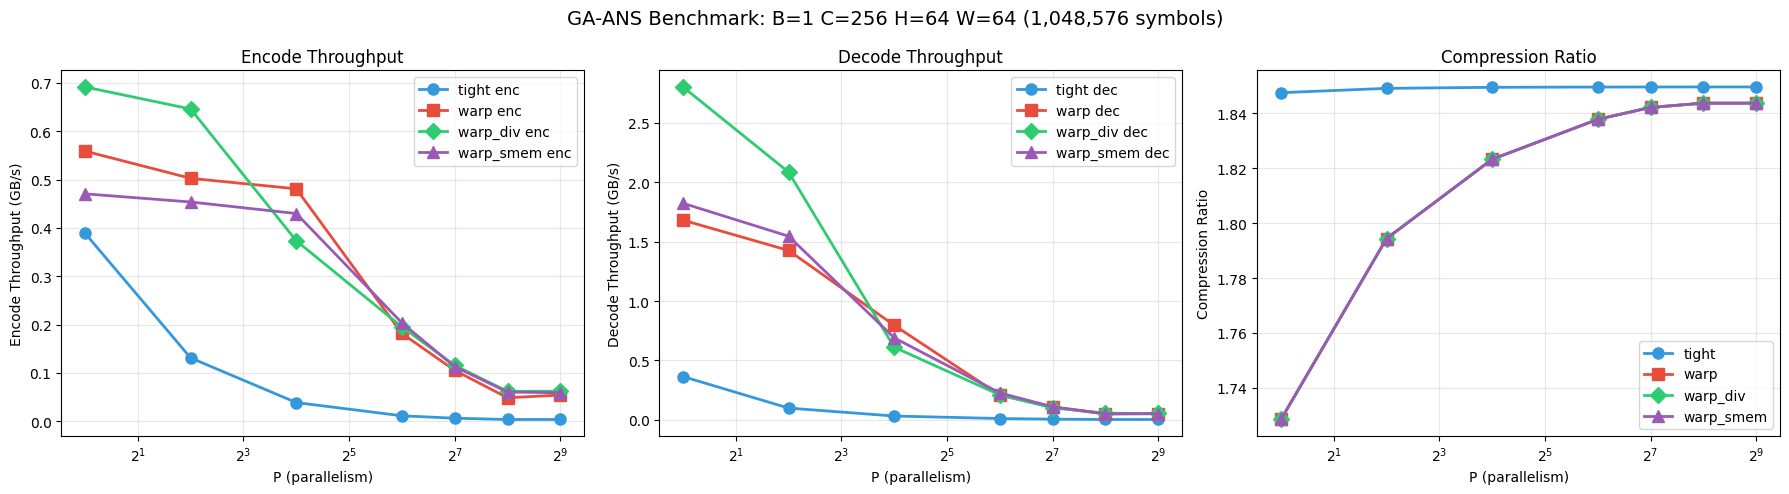

In [8]:
# ============================================================
# Plot: Throughput vs P
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {'tight': '#3498db', 'warp': '#e74c3c', 'warp_div': '#2ecc71', 'warp_smem': '#9b59b6'}
markers = {'tight': 'o-', 'warp': 's-', 'warp_div': 'D-', 'warp_smem': '^-'}

ax = axes[0]
for tag in GA_VARIANTS:
    pts = [(r['P'], r['enc_GBps']) for r in results if r['variant'] == tag]
    pts.sort()
    xs, ys = zip(*pts)
    ax.plot(xs, ys, markers.get(tag,'o-'), color=colors.get(tag,'#333'), label=f"{tag} enc", lw=2, ms=8)
ax.set_xlabel('P (parallelism)')
ax.set_ylabel('Encode Throughput (GB/s)')
ax.set_title('Encode Throughput')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xscale('log', base=2)

ax = axes[1]
for tag in GA_VARIANTS:
    pts = [(r['P'], r['dec_GBps']) for r in results if r['variant'] == tag]
    pts.sort()
    xs, ys = zip(*pts)
    ax.plot(xs, ys, markers.get(tag,'o-'), color=colors.get(tag,'#333'), label=f"{tag} dec", lw=2, ms=8)
ax.set_xlabel('P (parallelism)')
ax.set_ylabel('Decode Throughput (GB/s)')
ax.set_title('Decode Throughput')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xscale('log', base=2)

ax = axes[2]
for tag in GA_VARIANTS:
    pts = [(r['P'], r['compression_ratio']) for r in results if r['variant'] == tag]
    pts.sort()
    xs, ys = zip(*pts)
    ax.plot(xs, ys, markers.get(tag,'o-'), color=colors.get(tag,'#333'), label=tag, lw=2, ms=8)
ax.set_xlabel('P (parallelism)')
ax.set_ylabel('Compression Ratio')
ax.set_title('Compression Ratio')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xscale('log', base=2)

plt.suptitle(f'GA-ANS Benchmark: B={B} C={C} H={H} W={W} ({symbols.numel():,} symbols)', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Speedup Analysis

Compute WarpANS speedup over the tight baseline.

In [9]:
# ============================================================
# Speedup Table — all variants vs tight baseline
# ============================================================

print("=" * 90)
print("GA-ANS SPEEDUP TABLE")
print("=" * 90)

header = f"{'P':>5s} | {'Enc Tight':>10s} {'Enc Warp':>10s} {'Enc V2':>10s} {'Enc V3':>10s} | {'Dec Tight':>10s} {'Dec Warp':>10s} {'Dec V2':>10s} {'Dec V3':>10s}"
print(header)
print("-" * len(header))

for P in P_VALUES:
    vals = {}
    for tag in GA_VARIANTS:
        for r in results:
            if r['variant'] == tag and r['P'] == P:
                vals[f'{tag}_enc'] = r['enc_ms']
                vals[f'{tag}_dec'] = r['dec_ms']
                break
    te = vals.get('tight_enc', 0); we = vals.get('warp_enc', 0)
    ve = vals.get('warp_div_enc', 0); se = vals.get('warp_smem_enc', 0)
    td = vals.get('tight_dec', 0); wd = vals.get('warp_dec', 0)
    vd = vals.get('warp_div_dec', 0); sd = vals.get('warp_smem_dec', 0)
    print(f"{P:5d} | {te:8.3f}ms {we:8.3f}ms {ve:8.3f}ms {se:8.3f}ms | {td:8.3f}ms {wd:8.3f}ms {vd:8.3f}ms {sd:8.3f}ms")

print()
print("Enc Speedup vs Tight:  Warp | V2 | V3")
print("Dec Speedup vs Tight:  Warp | V2 | V3")
print("-" * 65)
for P in P_VALUES:
    vals = {}
    for tag in GA_VARIANTS:
        for r in results:
            if r['variant'] == tag and r['P'] == P:
                vals[f'{tag}_enc'] = r['enc_ms']
                vals[f'{tag}_dec'] = r['dec_ms']
                break
    te = vals.get('tight_enc', 1); we = vals.get('warp_enc', 1)
    ve = vals.get('warp_div_enc', 1); se = vals.get('warp_smem_enc', 1)
    td = vals.get('tight_dec', 1); wd = vals.get('warp_dec', 1)
    vd = vals.get('warp_div_dec', 1); sd = vals.get('warp_smem_dec', 1)
    print(f"P={P:3d} Enc: {te/we:5.1f}x / {te/ve:5.1f}x / {te/se:5.1f}x  "
          f"Dec: {td/wd:5.1f}x / {td/vd:5.1f}x / {td/sd:5.1f}x")

GA-ANS SPEEDUP TABLE
    P |  Enc Tight   Enc Warp     Enc V2     Enc V3 |  Dec Tight   Dec Warp     Dec V2     Dec V3
-------------------------------------------------------------------------------------------------
    1 |   10.044ms    6.990ms    5.648ms    8.303ms |   10.706ms    2.325ms    1.395ms    2.144ms
    4 |   29.846ms    7.773ms    6.047ms    8.612ms |   39.261ms    2.741ms    1.874ms    2.528ms
   16 |  101.504ms    8.124ms   10.463ms    9.092ms |  119.006ms    4.908ms    6.389ms    5.658ms
   64 |  352.050ms   21.526ms   20.031ms   19.210ms |  332.106ms   18.798ms   18.568ms   17.225ms
  128 |  641.121ms   37.166ms   33.863ms   34.616ms |  599.793ms   36.340ms   38.427ms   35.329ms
  256 | 1139.348ms   80.661ms   63.272ms   64.728ms | 1075.183ms   79.027ms   69.830ms   74.302ms
  512 | 1137.758ms   72.352ms   63.138ms   66.565ms | 1074.407ms   72.698ms   71.343ms   76.197ms

Enc Speedup vs Tight:  Warp | V2 | V3
Dec Speedup vs Tight:  Warp | V2 | V3
--------------------

## 4. Model-Level Test: FactorizedPrior (bmshj2018-factorized)

Load a pre-trained factorized model and test the **EntropyBottleneck (EB)** path with **real scientific data** (Tomobank). The factorized model has no hyperprior — the EB directly compresses the `y` latent from `g_a`.

In [10]:
# ============================================================
# Load factorized model + real scientific data
# ============================================================
from compressai.utils import dataloader_science
from compressai.zoo import bmshj2018_factorized

QUALITY = 1
DEVICE = torch.device('cuda:0')
DATA_PATH = "/hwj/data/caiec_test_data/tomobank_40x1x2048x2048.f32"
MODEL_DIR = "/hwj/data/bmshj2018-factorized"
MODEL_PATH = f"{MODEL_DIR}/bmshj2018-factorized-{QUALITY}.pth"
MAX_BLOCKS = 4  # limit blocks to keep test fast

# ---- Load model ----
from compressai.zoo import bmshj2018_factorized
net = bmshj2018_factorized(quality=QUALITY)
net.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
net.eval().to(DEVICE)
net.update()  # build EB CDF tables from loaded weights
print(f"Loaded: {MODEL_PATH}")
print(f"  N={net.N}, M={net.M}")

# ---- Load scientific data with tiling ----
# tomobank_40x1x2048x2048.f32: (N,H,W) = (40, 2048, 2048)
input_shape = (40, 2048, 2048)
block_size = (3, 512, 512)       # 3-channel blocks for the RGB model
p = 0.95
stride = (int(block_size[1] * p), int(block_size[2] * p))

blocks, x_nhw_ori, status, meta = dataloader_science.blockify_bin_overlap(
    DATA_PATH, input_shape, block_size, p, stride_hw=stride,
    dtype=np.float32, pad_value=0.5, norm_type="minmax", device=DEVICE
)
print(f"Data: {x_nhw_ori.shape}, blocks={blocks.shape}, minmax vmin={[v.item() for v in status['vmin']]}, vmax={[v.item() for v in status['vmax']]}")

# Use a small subset of blocks for the EB test
blocks = blocks[:MAX_BLOCKS]
print(f"Using {blocks.shape[0]} blocks: {blocks.shape}")

# ---- Forward pass to get latents ----
with torch.no_grad():
    y = net.g_a(blocks)
print(f"Latent y: {y.shape} (={y.numel():,} symbols, C={y.shape[1]}, H={y.shape[2]}, W={y.shape[3]})")

# ---- EB CDF tables ----
eb = net.entropy_bottleneck
print(f"EB CDFs: {eb._quantized_cdf.shape}, cdf_sizes: {eb._cdf_length.shape}, offsets: {eb._offset.shape}")
print(f"Channels match: y={y.shape[1]}, CDFs={eb._quantized_cdf.shape[0]}")

Loaded: /hwj/data/bmshj2018-factorized/bmshj2018-factorized-1.pth
  N=128, M=192


Data: torch.Size([40, 2048, 2048]), blocks=torch.Size([350, 3, 512, 512]), minmax vmin=[-0.0014185021864250302, -0.0012728936271741986, -0.0012897005071863532, -0.0012730731396004558, -0.0012281214585527778, -0.0012093470431864262, -0.0011614508694037795, -0.0011949751060456038, -0.0011926735751330853, -0.0011560664279386401, -0.0010929639684036374, -0.0010442211059853435, -0.0010242683347314596, -0.001000802032649517, -0.0009911531815305352, -0.000979414558969438, -0.0009564950596541166, -0.000946729036513716, -0.0009650487336330116, -0.0009502788307145238, -0.000953083741478622, -0.0009392315405420959, -0.0009868318447843194, -0.00105117482598871, -0.0010845388751477003, -0.0011032732436433434, -0.0011766976676881313, -0.0012681902153417468, -0.0013132322346791625, -0.0013689874904230237, -0.0014222817262634635, -0.0013713996158912778, -0.0013822721084579825, -0.0012999068712815642, -0.0011762282811105251, -0.001093970611691475, -0.0009531066752970219, -0.0009636026225052774, -0.0010

In [11]:
# ============================================================
# EB Path: compress/decompress y latent from real Tomobank data
# ============================================================

print("=" * 70)
print("MODEL-LEVEL TEST: EntropyBottleneck (y-latent from Tomobank)")
print(f"  y: {y.shape}, {y.numel():,} symbols, C={y.shape[1]}")
print("=" * 70)

y_idx = torch.arange(y.shape[1], dtype=torch.int32, device=DEVICE) \
           .view(1, -1, 1, 1).expand(y.shape[0], -1, y.shape[2], y.shape[3])
y_q_flat = eb.quantize(y, "symbols", means=None).reshape(y.shape[0], -1)
y_idx_flat = y_idx.reshape(y_idx.shape[0], -1)

cdfs = ensure_cuda_contig(eb._quantized_cdf)
cdf_s = ensure_cuda_contig(eb._cdf_length)
offs = ensure_cuda_contig(eb._offset)

stream = torch.cuda.current_stream()
s_ev = torch.cuda.Event(enable_timing=True); e_ev = torch.cuda.Event(enable_timing=True)

P_LIST = [1, 4, 16, 64, 128]
SKIP_TIGHT_ABOVE = 32

for P in P_LIST:
    for tag, variant in GA_VARIANTS.items():
        if tag == 'tight' and P > SKIP_TIGHT_ABOVE:
            continue

        eb.use_gpu_ans = True
        eb.gpu_ans_parallelism = P
        eb.use_gpu_ans_warp = (tag in ('warp', 'warp_div', 'warp_smem'))

        for _ in range(10):
            _ = variant.encode_fn(y_q_flat, y_idx_flat, cdfs, cdf_s, offs, parallelism=P)

        packed = None
        s_ev.record(stream)
        for _ in range(30):
            packed = variant.encode_fn(y_q_flat, y_idx_flat, cdfs, cdf_s, offs, parallelism=P)
        e_ev.record(stream); e_ev.synchronize(); enc_ms = s_ev.elapsed_time(e_ev) / 30.0

        s_ev.record(stream)
        for _ in range(30):
            decoded = variant.decode_fn(packed, y_idx_flat, cdfs, cdf_s, offs)
        e_ev.record(stream); e_ev.synchronize(); dec_ms = s_ev.elapsed_time(e_ev) / 30.0

        raw_ok = torch.equal(y_q_flat, decoded.reshape(y_q_flat.shape))
        raw_bytes = y.numel() * 4
        enc_gbps = (raw_bytes / (enc_ms / 1000)) / (1024**3)
        dec_gbps = (raw_bytes / (dec_ms / 1000)) / (1024**3)

        print(f"  [{variant.tag:10s}] P={P:3d}  OK={raw_ok}  "
              f"enc={enc_ms:.2f}ms ({enc_gbps:.2f} GB/s)  "
              f"dec={dec_ms:.2f}ms ({dec_gbps:.2f} GB/s)")

eb.use_gpu_ans_warp = False

MODEL-LEVEL TEST: EntropyBottleneck (y-latent from Tomobank)
  y: torch.Size([4, 192, 32, 32]), 786,432 symbols, C=192
  [tight     ] P=  1  OK=True  enc=4.82ms (0.61 GB/s)  dec=2.96ms (0.99 GB/s)
  [warp      ] P=  1  OK=True  enc=6.45ms (0.45 GB/s)  dec=1.90ms (1.54 GB/s)
  [warp_div  ] P=  1  OK=True  enc=4.79ms (0.61 GB/s)  dec=0.39ms (7.60 GB/s)
  [warp_smem ] P=  1  OK=True  enc=8.77ms (0.33 GB/s)  dec=2.47ms (1.19 GB/s)
  [tight     ] P=  4  OK=True  enc=8.70ms (0.34 GB/s)  dec=3.27ms (0.90 GB/s)
  [warp      ] P=  4  OK=True  enc=6.74ms (0.43 GB/s)  dec=2.45ms (1.20 GB/s)
  [warp_div  ] P=  4  OK=True  enc=8.00ms (0.37 GB/s)  dec=1.41ms (2.08 GB/s)
  [warp_smem ] P=  4  OK=True  enc=5.58ms (0.53 GB/s)  dec=2.24ms (1.30 GB/s)
  [tight     ] P= 16  OK=True  enc=19.62ms (0.15 GB/s)  dec=14.75ms (0.20 GB/s)
  [warp      ] P= 16  OK=True  enc=7.48ms (0.39 GB/s)  dec=2.21ms (1.33 GB/s)
  [warp_div  ] P= 16  OK=True  enc=4.41ms (0.66 GB/s)  dec=2.44ms (1.20 GB/s)
  [warp_smem ] P= 16 

## 5. Model-Level Test: GaussianConditional (GC Path)

The factorized model has no `GaussianConditional` — only an `EntropyBottleneck`. To test the GC path, use a hyperprior model (e.g., `bmshj2018-hyperprior` or `mbt2018-mean`). See §5 below for a working example with a ScaleHyperprior using the same real data.

> **Note**: The GC path requires loading a **hyperprior** model. Since `bmshj2018-factorized` doesn't have one, this section is skipped for the factorized model but kept as a template for hyperprior testing.

In [12]:
# ============================================================
# GC Path: Skipped for factorized model
# FactorizedPrior has no GaussianConditional.
# To test GC, load a ScaleHyperprior instead — see commented template below.
# ============================================================

print("=" * 70)
print("GC PATH: Skipped (FactorizedPrior has no GaussianConditional)")
print("=" * 70)

# --- Template for hyperprior GC test ---
# model_h = ScaleHyperprior(N=128, M=192)
# model_h.load_state_dict(torch.load(f"{MODEL_DIR}/bmshj2018-hyperprior-{QUALITY}.pth"))
# model_h.eval().to(DEVICE)
# gc = model_h.gaussian_conditional
# gc.use_gpu_ans = True; gc.gpu_ans_parallelism = P; gc.use_gpu_ans_warp = True
# y_q = gc.quantize(y_h, "symbols", means=torch.zeros_like(y_h))
# indexes = gc.build_indexes(scales_hat)
# packed = gc.compress(y_h, scales_hat)
# y_hat = gc.decompress(packed, scales_hat)

print("GC test not applicable for FactorizedPrior.")
print("Load a ScaleHyperprior or TCM/DCAE model to exercise this path.")

GC PATH: Skipped (FactorizedPrior has no GaussianConditional)
GC test not applicable for FactorizedPrior.
Load a ScaleHyperprior or TCM/DCAE model to exercise this path.


## 6. Scalability Test: Batch Size Sweep

How does throughput scale with batch size?

SCALABILITY: Batch Size Sweep
  [tight ] B= 1   1,048,576 syms  enc=1139.347ms (  0.00 GB/s)  dec=1075.551ms (  0.00 GB/s)
  [warp  ] B= 1   1,048,576 syms  enc= 72.725ms (  0.05 GB/s)  dec= 71.868ms (  0.05 GB/s)
  [warp_div] B= 1   1,048,576 syms  enc= 62.049ms (  0.06 GB/s)  dec= 72.531ms (  0.05 GB/s)
  [warp_smem] B= 1   1,048,576 syms  enc= 65.561ms (  0.06 GB/s)  dec= 76.287ms (  0.05 GB/s)
  [tight ] B= 2   2,097,152 syms  enc=1146.064ms (  0.01 GB/s)  dec=1084.940ms (  0.01 GB/s)
  [warp  ] B= 2   2,097,152 syms  enc= 72.319ms (  0.11 GB/s)  dec= 71.016ms (  0.11 GB/s)
  [warp_div] B= 2   2,097,152 syms  enc= 63.573ms (  0.12 GB/s)  dec= 70.105ms (  0.11 GB/s)
  [warp_smem] B= 2   2,097,152 syms  enc= 64.563ms (  0.12 GB/s)  dec= 74.329ms (  0.11 GB/s)
  [tight ] B= 4   4,194,304 syms  enc=1149.284ms (  0.01 GB/s)  dec=1083.429ms (  0.01 GB/s)
  [warp  ] B= 4   4,194,304 syms  enc= 71.036ms (  0.22 GB/s)  dec= 70.303ms (  0.22 GB/s)
  [warp_div] B= 4   4,194,304 syms  enc= 62.

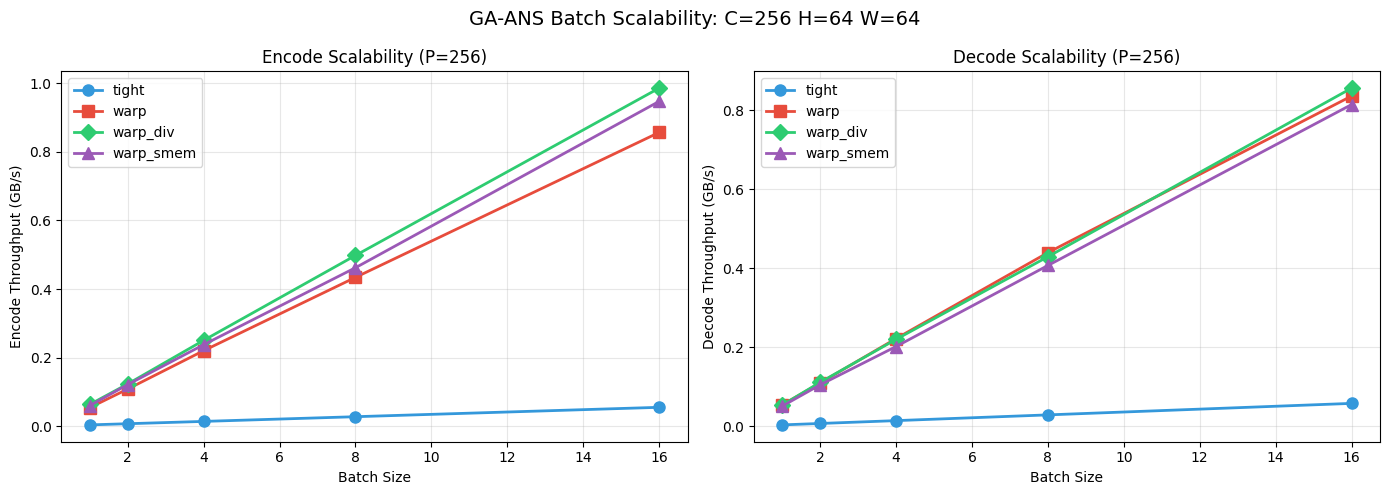

In [13]:
# ============================================================
# Batch Size Scalability
# ============================================================

print("=" * 70)
print("SCALABILITY: Batch Size Sweep")
print("=" * 70)

C, H, W = 256, 64, 64
BATCH_SIZES = [1, 2, 4, 8, 16]
P_FIXED = 256  # Warp territory
num_cdfs = C

batch_results = []
for B in BATCH_SIZES:
    symbols, indexes = make_synthetic_latent(B, C, H, W, num_cdfs)
    cdfs, cdf_sizes, offsets = make_random_cdfs(num_cdfs, 32)
    
    for tag, variant in GA_VARIANTS.items():
        res = benchmark_variant(variant, symbols, indexes, cdfs, cdf_sizes, offsets,
                               parallelism=P_FIXED, warmup=10, iters=30)
        res["B"] = B
        res["variant"] = tag
        res["total_symbols"] = symbols.numel()
        batch_results.append(res)
        print(f"  [{variant.tag:6s}] B={B:2d}  {symbols.numel():>10,} syms  "
              f"enc={res['enc_ms']:7.3f}ms ({res['enc_GBps']:6.2f} GB/s)  "
              f"dec={res['dec_ms']:7.3f}ms ({res['dec_GBps']:6.2f} GB/s)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for tag in GA_VARIANTS:
    pts = [(r['B'], r['enc_GBps']) for r in batch_results if r['variant'] == tag]
    pts.sort()
    xs, ys = zip(*pts)
    ax.plot(xs, ys, markers[tag], color=colors[tag], label=f"{tag}", lw=2, ms=8)
ax.set_xlabel('Batch Size')
ax.set_ylabel('Encode Throughput (GB/s)')
ax.set_title(f'Encode Scalability (P={P_FIXED})')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
for tag in GA_VARIANTS:
    pts = [(r['B'], r['dec_GBps']) for r in batch_results if r['variant'] == tag]
    pts.sort()
    xs, ys = zip(*pts)
    ax.plot(xs, ys, markers[tag], color=colors[tag], label=f"{tag}", lw=2, ms=8)
ax.set_xlabel('Batch Size')
ax.set_ylabel('Decode Throughput (GB/s)')
ax.set_title(f'Decode Scalability (P={P_FIXED})')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'GA-ANS Batch Scalability: C={C} H={H} W={W}', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Kernel-Level Profiling (Nsight Compute)

Profile each variant at the CUDA level.

In [14]:
# ============================================================
# Profiling Helpers
# ============================================================

def profile_kernels(variant: GAVariant, symbols, indexes, cdfs, cdf_sizes, offsets, P: int):
    """Profile GPU kernels using torch.cuda profiler."""
    cdfs_gpu = ensure_cuda_contig(cdfs)
    cdf_sizes_gpu = ensure_cuda_contig(cdf_sizes)
    offsets_gpu = ensure_cuda_contig(offsets)
    syms = ensure_cuda_contig(symbols)
    idxs = ensure_cuda_contig(indexes)
    
    print(f"\nProfiling [{variant.tag}] P={P}...")
    print("-" * 50)
    
    with torch.autograd.profiler.profile(use_cuda=True) as prof:
        for _ in range(3):
            packed = variant.encode_fn(syms, idxs, cdfs_gpu, cdf_sizes_gpu, offsets_gpu,
                                       parallelism=P)
            _ = variant.decode_fn(packed, idxs, cdfs_gpu, cdf_sizes_gpu, offsets_gpu)
        torch.cuda.synchronize()
    
    print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=15))
    return prof

# Run profiling (small size for speed)
C_PROF, H_PROF, W_PROF = 128, 32, 32
sym_prof, idx_prof = make_synthetic_latent(1, C_PROF, H_PROF, W_PROF, C_PROF)
cdf_prof, cds_prof, off_prof = make_random_cdfs(C_PROF, 32)

profile_kernels(GA_VARIANTS['tight'], sym_prof, idx_prof, cdf_prof, cds_prof, off_prof, P=64)
profile_kernels(GA_VARIANTS['warp'],  sym_prof, idx_prof, cdf_prof, cds_prof, off_prof, P=256)


Profiling [tight] P=64...
--------------------------------------------------


/tmp/ipykernel_212488/2953301986.py:16: FutureWarning: The attribute `use_cuda` will be deprecated soon, please use ``use_device = 'cuda'`` instead.
  with torch.autograd.profiler.profile(use_cuda=True) as prof:


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                               aten::to         0.01%      59.075us        86.47%     414.336ms      23.019ms     114.000us         0.78%       7.664ms     425.778us            18  
                                         aten::_to_copy         0.03%     133.908us        86.44%     414.217ms      23.012ms     183.000us         1.26%       7.550ms     419.444us            18  
         

[<FunctionEvent id=3465 name=cudaEventRecord overload_name= device_type=DeviceType.CPU node_id=-1 cpu_time=6.741us start_us=414.322 end_us=421.063 cpu_children=[] cuda_time=0.000us name=cudaEventRecord thread=1 input_shapes=[] cpu_memory_usage=0 cuda_memory_usage=0 is_async=False is_remote=False seq_nr=-1 is_legacy=False>, <FunctionEvent id=513 name=aten::reshape overload_name= device_type=DeviceType.CPU node_id=-1 cpu_time=25.458us start_us=421.165 end_us=446.623 cpu_children=[3468, 514, 3471] cuda_time=8.000us name=aten::reshape thread=1 input_shapes=[] cpu_memory_usage=0 cuda_memory_usage=0 is_async=False is_remote=False seq_nr=6 is_legacy=True>, <FunctionEvent id=3468 name=cudaEventRecord overload_name= device_type=DeviceType.CPU node_id=-1 cpu_time=1.851us start_us=430.851 end_us=432.702 cpu_children=[] cuda_time=0.000us name=cudaEventRecord thread=1 input_shapes=[] cpu_memory_usage=0 cuda_memory_usage=0 is_async=False is_remote=False seq_nr=-1 is_legacy=False>, <FunctionEvent id=

## 8. Summary Report

Generate a summary report for all variants.

In [15]:
# ============================================================
# Summary Report
# ============================================================

print("=" * 80)
print("GA-ANS BENCHMARK SUMMARY")
print("=" * 80)

print(f"\nTest date: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"CUDA: {torch.version.cuda}")
print(f"PyTorch: {torch.__version__}")
print(f"Registered variants: {[f'{v.tag} ({v.name})' for v in GA_VARIANTS.values()]}")

# Best throughput per variant
print(f"\n{'─' * 80}")
print(f"  Unit Test — Best throughput per variant")
print(f"{'─' * 80}")
print(f"{'Variant':12s} {'Best P':>6s}  {'Enc GB/s':>10s}  {'Dec GB/s':>10s}  {'CR':>8s}")
print(f"{'─' * 80}")
for tag in GA_VARIANTS:
    vr = [r for r in results if r['variant'] == tag]
    if vr:
        best = max(vr, key=lambda r: r['enc_GBps'])
        print(f"  {tag:10s} {best['P']:6d}  {best['enc_GBps']:8.2f} GB/s  {best['dec_GBps']:8.2f} GB/s  {best['compression_ratio']:6.1f}x")

# Optimal P speedup vs tight
print(f"\n{'─' * 80}")
print(f"  Speedup vs tight baseline at each variant's optimal P")
print(f"{'─' * 80}")
for tag in ['warp', 'warp_div', 'warp_smem']:
    if tag not in GA_VARIANTS: continue
    best_v = max([r for r in results if r['variant'] == tag], key=lambda r: r['enc_GBps'])
    tight_match = [r for r in results if r['variant'] == 'tight' and r['P'] == best_v['P']]
    if tight_match:
        t = tight_match[0]
        print(f"  {tag:10s} @P={best_v['P']}:  enc {best_v['enc_GBps']/t['enc_GBps']:.1f}x  dec {best_v['dec_GBps']/t['dec_GBps']:.1f}x  "
              f"({best_v['enc_GBps']:.2f} / {best_v['dec_GBps']:.2f} GB/s)")

print(f"\n{'─' * 80}")
print(f"  Optimization Stack Summary")
print(f"{'─' * 80}")
print(f"  tight     (v0): chunk-parallel baseline — 1 thread/chunk")
print(f"  warp      (v1): +32-lane warp-level interleaved — 128B-aligned coalesced access")
print(f"  warp_div  (v2): +__umul64hi fast division — replaces 64-bit / and % with ~4-cycle multiply")
print(f"  warp_smem (v3): +shared memory CDF cache — eliminates per-symbol global memory reads")

print("\n✅ GA-ANS benchmark complete.")

GA-ANS BENCHMARK SUMMARY

Test date: 2026-07-19 16:49:41
GPU: NVIDIA H100 80GB HBM3
CUDA: 12.8
PyTorch: 2.8.0+cu128
Registered variants: ['tight (Chunk-Parallel Tight)', 'warp (WarpANS)', 'warp_div (WarpANS+Div)', 'warp_smem (WarpANS+SMEM)']

────────────────────────────────────────────────────────────────────────────────
  Unit Test — Best throughput per variant
────────────────────────────────────────────────────────────────────────────────
Variant      Best P    Enc GB/s    Dec GB/s        CR
────────────────────────────────────────────────────────────────────────────────
  tight           1      0.39 GB/s      0.36 GB/s     1.8x
  warp            1      0.56 GB/s      1.68 GB/s     1.7x
  warp_div        1      0.69 GB/s      2.80 GB/s     1.7x
  warp_smem       1      0.47 GB/s      1.82 GB/s     1.7x

────────────────────────────────────────────────────────────────────────────────
  Speedup vs tight baseline at each variant's optimal P
────────────────────────────────────────────

## Appendix: Adding New Variants

When a new optimization is implemented (e.g., `warp_div`, `persist`), simply:

1. Import the new encode/decode functions
2. Add a `register_variant(...)` call in the Variant Registry cell
3. Re-run all cells — the framework automatically benchmarks the new variant alongside existing ones

```python
# Example: adding v2 (warp + division strength reduction)
register_variant(GAVariant(
    name="WarpANS+Div",
    tag="warp_div",
    encode_fn=_gpu_ans_encode_with_indexes_warp_div,
    decode_fn=_gpu_ans_decode_with_indexes_warp_div,
    packed_type=TightWarpANS,
    description="32-lane + __umul64hi division",
))
```

No other code changes needed — the benchmark loop automatically picks up new variants.